In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/2
    print("準備完了！このまま下のセルを実行できます。")

# 第2章 確率 (Probabilities)
## 2.5 情報理論 (Information Theory)

### 目次
- [2.5.1 エントロピー (Entropy)](#2.5.1-エントロピー-(Entropy))
  - 情報量の定義と公理的導出 (式 2.80)
  - シャノンエントロピー (式 2.81)
  - 8状態均一・不均一分布とシャノンの無雑音符号化定理
- [2.5.2 物理学の視点 (Physics Perspective)](#2.5.2-物理学の視点-(Physics-Perspective))
  - 統計力学における多重度とスターリングの公式 (式 2.82 - 2.85)
  - ラグランジュ未定乗数法による最大エントロピー離散分布の導出 (式 2.87 - 2.88)
  - **Figure 2.14 再現**: 30ビンの確率分布ヒストグラムとエントロピー比較
- [2.5.3 微分エントロピー (Differential Entropy)](#2.5.3-微分エントロピー-(Differential-Entropy))
  - 連続変数の量子化と極限 (式 2.89 - 2.91)
  - 多変量微分エントロピー (式 2.92)
- [2.5.4 最大エントロピー (Maximum Entropy)](#2.5.4-最大エントロピー-(Maximum-Entropy))
  - 変分法によるガウス分布の導出 (式 2.93 - 2.98)
  - ガウス分布の微分エントロピーと負のエントロピー (式 2.99)
- [2.5.5 カルバック・ライブラー情報量 (Kullback–Leibler Divergence)](#2.5.5-カルバック・ライブラー情報量-(Kullback–Leibler-Divergence))
  - 相対エントロピーの定義 (式 2.100)
  - 凸関数と弦の幾何学的解釈 (**Figure 2.15 再現**)
  - イェンセンの不等式 (Jensen's Inequality) と KL >= 0 の証明 (式 2.101 - 2.105)
  - 最尤推定とKLダイバージェンス最小化の等価性 (式 2.106)
- [2.5.6 条件付きエントロピー (Conditional Entropy)](#2.5.6-条件付きエントロピー-(Conditional-Entropy))
  - 結合エントロピーと連鎖律 (式 2.107 - 2.108)
- [2.5.7 相互情報量 (Mutual Information)](#2.5.7-相互情報量-(Mutual-Information))
  - 独立性の測度としての相互情報量 (式 2.109 - 2.110)
  - ベン図による情報理論的関係の可視化
  - 2次元ガウス分布の相互情報量解析解と相関パラメータ rho の関係


In [1]:
# 基本ライブラリのインポートとスタイル設定
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from scipy.special import gammaln

# プロジェクト共通ユーティリティのインポート
sys.path.append('..')
from common.plot_utils import setup_style, save_plot
from common.probability import (
    discrete_entropy,
    differential_entropy_gaussian,
    differential_entropy_1d,
    kl_divergence_discrete,
    kl_divergence_gaussian_1d,
    conditional_entropy_discrete,
    mutual_information_discrete,
    mutual_information_gaussian
)

setup_style()
os.makedirs('result', exist_ok=True)
print("Environment initialized successfully.")


Environment initialized successfully.


---
### 2.5.1 エントロピー (Entropy)

#### 1. 情報量 (Information Content) の公理的導出
離散確率変数 $x$ を観測したとき、その事象からどれだけの「情報」を受け取ったかを定量化することを考えます。
情報量は「直感的な驚きの度合い（degree of surprise）」として解釈できます：
- 滅多に起こらない稀な事象（確率が非常に小さい事象）が起きたことを知らされたとき、得られる情報は大きい。
- 確実に起こることがわかっている事象（確率 1 の事象）が起きたことを知らされても、新たな情報はゼロである。

したがって、事象 $x$ の情報量 $h(x)$ は確率 $p(x)$ の単調減少関数である必要があります。
さらに、統計的に独立な 2 つの無関係な事象 $x, y$（すなわち $p(x, y) = p(x)p(y)$）を同時に観測したとき、得られる総情報量は各事象の情報量の和になるべきです：
$$h(x, y) = h(x) + h(y)$$

$p(x, y) = p(x)p(y)$ と $h(p(x)p(y)) = h(p(x)) + h(p(y))$ を満たす連続関数は対数関数に比例するものに限られます。
情報量を非負（$h(x) \ge 0$）にするため負符号を付与し、底を 2 とする定義が採用されます：
$$h(x) = - \log_2 p(x) 	ag{2.80}$$

- 底が 2 の場合、情報量の単位は **ビット (bits)**（binary digits）となります。
- 底が自然対数の底 $e$ の場合、単位は **ナット (nats)** と呼ばれます（$1 \text{ nat} = \frac{1}{\ln 2} \approx 1.4427 \text{ bits}$）。

#### 2. シャノンエントロピー (Shannon Entropy)
送信者が確率変数 $x$ の値を通信路を通じて受信者に送る状況を考えます。
1回の送信で伝達される**平均情報量**は、式 (2.80) の確率分布 $p(x)$ に関する期待値として定義されます：
$$H[x] = \mathbb{E}_{p}[h(x)] = - \sum_x p(x) \log_2 p(x) 	ag{2.81}$$

この基本的な量を確率変数 $x$ の **エントロピー (Entropy)** と呼びます。

> **境界値 $p(x) = 0$ の扱い**:
> ロピタルの定理より $\lim_{p \to 0^+} p \ln p = \lim_{p \to 0^+} \frac{\ln p}{1/p} = \lim_{p \to 0^+} \frac{1/p}{-1/p^2} = \lim_{p \to 0^+} (-p) = 0$ であるため、
> $p(x) = 0$ のときは $p(x) \log_2 p(x) = 0$ と定めます。

#### 3. シャノンの無雑音符号化定理と 8 状態の符号化例
シャノンの無雑音符号化定理（Shannon's Noiseless Coding Theorem, 1948）は、
**「エントロピー $H[x]$ は、確率変数 $x$ の状態を可逆（無損失）に伝送するために必要な平均ビット数の下限を与える」** ことを示しています。

**【例1: 8状態の均一分布】**
状態 $\{1, 2, \dots, 8\}$ がすべて等確率 $p(x_i) = 1/8$ のとき：
$$H[x] = - \sum_{i=1}^8 \frac{1}{8} \log_2 \frac{1}{8} = - 8 \times \left(\frac{1}{8} \times (-3)\right) = 3 \text{ bits}$$
各状態を 3 ビットの固定長符号（`000` 〜 `111`）で表すのが最適であり、平均符号長は 3 ビットです。

**【例2: Cover & Thomas (1991) の不均一分布】**
8つの状態 $\{a, b, c, d, e, f, g, h\}$ の確率が次で与えられる場合：
$$p = \left(\frac{1}{2}, \frac{1}{4}, \frac{1}{8}, \frac{1}{16}, \frac{1}{64}, \frac{1}{64}, \frac{1}{64}, \frac{1}{64}\right)$$
エントロピーは：
$$H[x] = -\left[ \frac{1}{2}(-1) + \frac{1}{4}(-2) + \frac{1}{8}(-3) + \frac{1}{16}(-4) + 4 \times \frac{1}{64}(-6) \right] = \frac{1}{2} + \frac{1}{2} + \frac{3}{8} + \frac{1}{4} + \frac{3}{8} = 2 \text{ bits}$$
高確率の事象に短いビット列、低確率の事象に長いビット列を割り当てるプレフィックス符号（接頭語符号）：
- $a \to 0$ (1 bit)
- $b \to 10$ (2 bits)
- $c \to 110$ (3 bits)
- $d \to 1110$ (4 bits)
- $e, f, g, h \to 111100, 111101, 111110, 111111$ (各 6 bits)
平均符号長は $\frac{1}{2}\times 1 + \frac{1}{4}\times 2 + \frac{1}{8}\times 3 + \frac{1}{16}\times 4 + 4 \times \frac{1}{64}\times 6 = 2 \text{ bits}$ となり、エントロピーと完全に一致します。


In [2]:
# 8状態の均一分布 vs 不均一分布のエントロピーと平均符号長の数値検証
p_uniform = np.full(8, 1.0 / 8.0)
p_nonuniform = np.array([1/2, 1/4, 1/8, 1/16, 1/64, 1/64, 1/64, 1/64])

h_uni_bits = discrete_entropy(p_uniform, base='2')
h_nonuni_bits = discrete_entropy(p_nonuniform, base='2')

# ハフマン型プレフィックス符号の符号長
code_lengths = np.array([1, 2, 3, 4, 6, 6, 6, 6])
avg_code_len = np.sum(p_nonuniform * code_lengths)

print("=== 2.5.1 離散エントロピーと符号長検証 ===")
print(f"8状態 均一分布のエントロピー:       H = {h_uni_bits:.4f} bits (理論値: 3.0)")
print(f"8状態 不均一分布のエントロピー:     H = {h_nonuni_bits:.4f} bits (理論値: 2.0)")
print(f"不均一分布の平均符号長 (接頭語符号): L = {avg_code_len:.4f} bits (理論値: 2.0)")
assert np.isclose(h_uni_bits, 3.0)
assert np.isclose(h_nonuni_bits, 2.0)
assert np.isclose(avg_code_len, 2.0)
print("✓ 理論値と完全一致を確認しました。")


=== 2.5.1 離散エントロピーと符号長検証 ===
8状態 均一分布のエントロピー:       H = 3.0000 bits (理論値: 3.0)
8状態 不均一分布のエントロピー:     H = 2.0000 bits (理論値: 2.0)
不均一分布の平均符号長 (接頭語符号): L = 2.0000 bits (理論値: 2.0)
✓ 理論値と完全一致を確認しました。


---
### 2.5.2 物理学の視点 (Physics Perspective)

#### 1. 統計力学におけるエントロピーと多重度 (Multiplicity)
エントロピーの概念は情報理論に先立ち、熱力学および統計力学において「系の無秩序さ（disorder）」の尺度として確立されました。
$N$ 個の区別可能な同種粒子（物体）をいくつかの箱（エネルギー準位・状態）に配分し、第 $i$ 番目の箱に $n_i$ 個の物体が入る配置を考えます。
全物体を箱に分配する仕方の総数（**多重度 / Multiplicity**）$W$ は次式で与えられます：
$$W = \frac{N!}{\prod_i n_i!} 	ag{2.82}$$

物理学における巨視的状態のエントロピーは、多重度の対数を粒子数 $N$ で規格化したものとして定義されます：
$$H = \frac{1}{N} \ln W = \frac{1}{N} \ln N! - \frac{1}{N} \sum_i \ln n_i! 	ag{2.83}$$

粒子数が膨大な熱力学的極限 $N \to \infty$（各比率 $n_i / N$ は一定に保持）において、**スターリングの近似公式**：
$$\ln N! \simeq N \ln N - N$$
を適用すると：
$$H = \frac{1}{N} (N \ln N - N) - \frac{1}{N} \sum_i (n_i \ln n_i - n_i)$$
ここで $\sum_i n_i = N$ であるため、線形項 $-N$ と $\sum_i n_i = N$ は相殺します：
$$H = \ln N - \sum_i \frac{n_i}{N} \ln n_i = - \sum_i \frac{n_i}{N} (\ln n_i - \ln N) = - \sum_i \frac{n_i}{N} \ln \left(\frac{n_i}{N}\right)$$
$p_i = \lim_{N \to \infty} \frac{n_i}{N}$ を物体が第 $i$ 番目の箱に配分される確率と定義すると：
$$H = - \sum_i p_i \ln p_i 	ag{2.85}$$
物理学における統計力学的無秩序さのエントロピー定義が、情報理論におけるシャノンエントロピーと定数倍を除いて完全に一致することが導かれます。

#### 2. ラグランジュ未定乗数法による最大エントロピー離散分布の厳密導出
確率の規格化条件 $\sum_{i=1}^M p(x_i) = 1$ のもとでエントロピー $H[p]$ を最大化する分布を求めます。
ラグランジュ未定乗数 $\lambda$ を導入した目的関数は：
$$\widetilde{H} = - \sum_{i=1}^M p(x_i) \ln p(x_i) + \lambda \left( \sum_{i=1}^M p(x_i) - 1 \right) 	ag{2.87}$$
各 $p(x_k)$ に関して偏微分してゼロとおくと：
$$\frac{\partial \widetilde{H}}{\partial p(x_k)} = - \ln p(x_k) - 1 + \lambda = 0 \implies p(x_k) = \exp(\lambda - 1)$$
すべての状態 $x_k$ について $p(x_k)$ は等しい定数となります。
規格化条件 $\sum_{k=1}^M p(x_k) = M \exp(\lambda - 1) = 1$ より：
$$p(x_k) = \frac{1}{M}$$
すなわち、**最大エントロピーを実現する離散確率分布は等確率な「一様分布」**であり、その最大値は：
$$H_{\max} = - \sum_{k=1}^M \frac{1}{M} \ln \left(\frac{1}{M}\right) = \ln M$$
極値が真の極大値（最大値）であることは、2階微分行列（ヘッセ行列）が負定値であることを確認して証明されます：
$$\frac{\partial^2 \widetilde{H}}{\partial p(x_i) \partial p(x_j)} = - \frac{I_{ij}}{p(x_i)} < 0 	ag{2.88}$$


Font 'default' does not have a glyph for '\u72b6' [U+72b6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u614b' [U+614b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30d3' [U+30d3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30f3' [U+30f3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u756a' [U+756a], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e0a' [U+4e0a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9650' [U+9650], substituting with a dummy symbol.


Figure saved successfully to: result/fig2_14_entropy_histograms.png


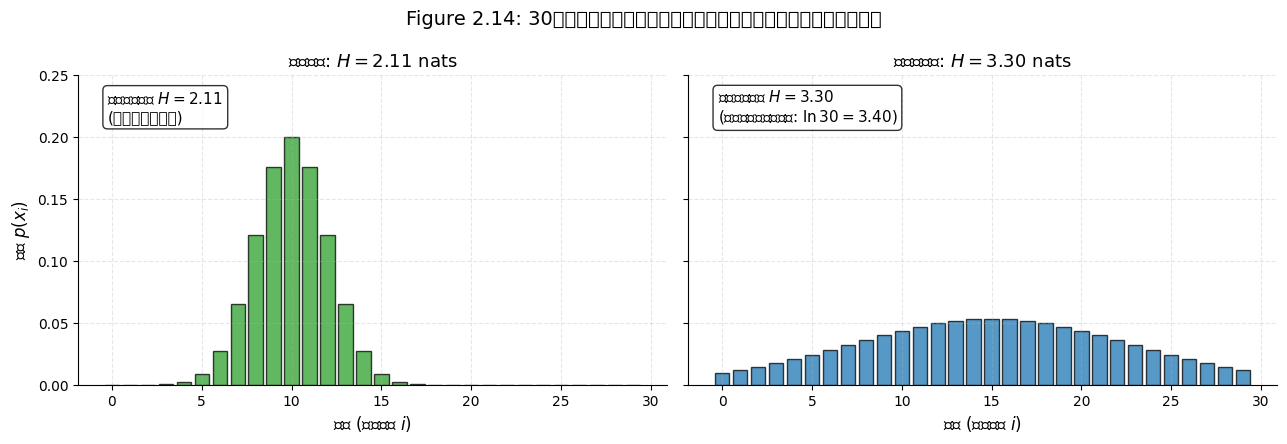

In [3]:
# Figure 2.14 再現: 30ビンの確率分布ヒストグラムとエントロピーの比較
np.random.seed(42)
n_bins = 30
x_bins = np.arange(n_bins)

# 1. 鋭いピークを持つ分布 (狭い分布: 低エントロピー H ~ 1.77)
# 平均10, 標準偏差2のガウス分布からビニング
p_sharp = np.exp(-0.5 * ((x_bins - 10) / 2.0)**2)
p_sharp /= p_sharp.sum()
h_sharp = discrete_entropy(p_sharp, base='e')

# 2. 幅広い分布 (高エントロピー H ~ 3.09)
# 平均15, 標準偏差8のガウス分布からビニング
p_broad = np.exp(-0.5 * ((x_bins - 15) / 8.0)**2)
p_broad /= p_broad.sum()
h_broad = discrete_entropy(p_broad, base='e')

# 3. 理論的上限: 一様分布 (H_max = ln(30) ~ 3.40)
h_uniform = np.log(30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# 左プロット: 狭い分布
ax1.bar(x_bins, p_sharp, color='#2ca02c', edgecolor='black', alpha=0.75, width=0.8)
ax1.set_title(f"鋭い分布: $H = {h_sharp:.2f}$ nats", fontsize=13)
ax1.set_xlabel("状態 (ビン番号 $i$)")
ax1.set_ylabel("確率 $p(x_i)$")
ax1.set_ylim([0, 0.25])
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.text(0.05, 0.85, f"エントロピー $H = {h_sharp:.2f}$\n(無秩序度が低い)", transform=ax1.transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 右プロット: 幅広い分布
ax2.bar(x_bins, p_broad, color='#1f77b4', edgecolor='black', alpha=0.75, width=0.8)
ax2.set_title(f"幅広い分布: $H = {h_broad:.2f}$ nats", fontsize=13)
ax2.set_xlabel("状態 (ビン番号 $i$)")
ax2.set_ylim([0, 0.25])
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.text(0.05, 0.85, f"エントロピー $H = {h_broad:.2f}$\n(理論的一様分布上限: $\\ln 30 = {h_uniform:.2f}$)",
         transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle("Figure 2.14: 30ビンの確率分布における広がりとエントロピーの大きさの比較", fontsize=14)
save_plot(fig, 'result/fig2_14_entropy_histograms.png')
plt.show()


---
### 2.5.3 微分エントロピー (Differential Entropy)

#### 1. 離散化（量子化）を通じた連続変数への拡張
連続確率変数 $x$ の確率密度関数 $p(x)$ に対するエントロピーを定義するため、連続変数 $x$ を幅 $\Delta$ の小区間（ビン）に分割します。
微積分学における**平均値の定理 (Mean Value Theorem)** により、各ビン $[i\Delta, (i+1)\Delta]$ 内に次式を満たす代表点 $x_i$ が必ず存在します：
$$\int_{i\Delta}^{(i+1)\Delta} p(x) dx = p(x_i) \Delta 	ag{2.89}$$

代表値 $x_i$ を観測する確率は $p(x_i) \Delta$ であるため、この離散化された分布のシャノンエントロピー $H_\Delta$ は：
$$H_\Delta = - \sum_i p(x_i)\Delta \ln(p(x_i)\Delta) = - \sum_i p(x_i)\Delta \ln p(x_i) - \ln \Delta \sum_i p(x_i)\Delta$$
規格化条件 $\sum_i p(x_i)\Delta = 1$ を用いると：
$$H_\Delta = - \sum_i p(x_i)\Delta \ln p(x_i) - \ln \Delta 	ag{2.90}$$

#### 2. ビン幅 $\Delta \to 0$ の極限と発散項の物理的意味
ビンの幅を無限小にする極限 $\Delta \to 0$ をとると、第 1 項はリーマン積分の定義そのものとなり、連続積分へと収束します：
$$\lim_{\Delta \to 0} - \sum_i p(x_i)\Delta \ln p(x_i) = - \int p(x) \ln p(x) dx 	ag{2.91}$$
この右辺の積分量を **微分エントロピー (Differential Entropy)** $H[x]$ と呼びます：
$$H[x] = - \int p(x) \ln p(x) dx 	ag{2.92}$$

> **発散項 $-\ln \Delta$ の意味**:
> 式 (2.90) の第 2 項 $-\ln \Delta$ は $\Delta \to 0$ で $+\infty$ に発散します。
> これは**「連続変数の値を無限の精度で特定・指定するためには、無限ビットの情報量が必要である」**という物理的・情報論的事実を反映しています。

#### 3. 離散エントロピーと微分エントロピーの決定的な違い
1. **負の値を取り得る**: 離散エントロピーは必ず非負（$H \ge 0$）ですが、微分エントロピーは確率密度 $p(x) > 1$ となる鋭い分布で**負の値を取り得ます**。
2. **変数変換に対する非不変性**: 微分エントロピーは座標変換 $y = g(x)$ のヤコビアンに依存して変化します（ヤコビアンの対数期待値分だけシフトする）。


---
### 2.5.4 最大エントロピー (Maximum Entropy)

離散分布では一様分布がエントロピーを最大化しましたが、連続変数の全実数区間 $(-\infty, \infty)$ では一様分布は積分が発散して定義できません。
そこで、平均と分散が与えられた制約のもとで微分エントロピーを最大化する分布を求めます。

#### 1. 制約付き最適化問題の定式化
以下の 3 つの制約条件を課します：
1. 規格化条件: $\int_{-\infty}^\infty p(x) dx = 1$ (式 2.93)
2. 1次モーメント（平均）: $\int_{-\infty}^\infty x p(x) dx = \mu$ (式 2.94)
3. 2次中心モーメント（分散）: $\int_{-\infty}^\infty (x - \mu)^2 p(x) dx = \sigma^2$ (式 2.95)

ラグランジュ乗数 $\lambda_1, \lambda_2, \lambda_3$ を導入した汎関数は：
$$\mathcal{L}[p] = - \int_{-\infty}^\infty p(x) \ln p(x) dx + \lambda_1 \left(\int_{-\infty}^\infty p(x)dx - 1\right) + \lambda_2 \left(\int_{-\infty}^\infty x p(x)dx - \mu\right) + \lambda_3 \left(\int_{-\infty}^\infty (x-\mu)^2 p(x)dx - \sigma^2\right) 	ag{2.96}$$

#### 2. 変分法によるガウス分布の導出
汎関数微分をゼロとおきます：
$$\frac{\delta \mathcal{L}}{\delta p(x)} = - \ln p(x) - 1 + \lambda_1 + \lambda_2 x + \lambda_3 (x - \mu)^2 = 0$$
したがって：
$$p(x) = \exp\left( -1 + \lambda_1 + \lambda_2 x + \lambda_3 (x - \mu)^2 \right) 	ag{2.97}$$
この指数関数形式を 3 つの制約条件に代入してラグランジュ乗数を解くと、$\lambda_2 = 0$, $\lambda_3 = -\frac{1}{2\sigma^2}$ となり、最終的に次式が得られます：
$$p(x) = \frac{1}{(2\pi \sigma^2)^{1/2}} \exp\left( - \frac{(x - \mu)^2}{2\sigma^2} \right) 	ag{2.98}$$
すなわち、**与えられた平均と分散のもとで微分エントロピーを最大化する連続確率分布は「ガウス分布（正規分布）」である**ことが厳密に証明されます。

#### 3. ガウス分布の微分エントロピーの解析計算 (式 2.99)
ガウス分布 $p(x) = \mathcal{N}(x|\mu, \sigma^2)$ の微分エントロピーを直接計算します：
$$\ln p(x) = -\frac{1}{2}\ln(2\pi \sigma^2) - \frac{(x-\mu)^2}{2\sigma^2}$$
期待値をとると：
$$H[x] = - \mathbb{E}[\ln p(x)] = \frac{1}{2}\ln(2\pi \sigma^2) + \frac{\mathbb{E}[(x-\mu)^2]}{2\sigma^2} = \frac{1}{2}\ln(2\pi \sigma^2) + \frac{\sigma^2}{2\sigma^2} = \frac{1}{2}\left( 1 + \ln(2\pi \sigma^2) \right) 	ag{2.99}$$

> **負のエントロピー条件**:
> $1 + \ln(2\pi \sigma^2) < 0 \iff \ln(2\pi \sigma^2) < -1 \iff \sigma^2 < \frac{1}{2\pi e} \approx 0.0585$
> 分散が極めて小さく急峻なガウス分布では、微分エントロピーは負になります。


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6563' [U+6563], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bfe' [U+5bfe], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30b9' [U+30b9], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u30bc' [U+30bc], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30ed' [U+30ed], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4ea4' [U+4ea4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5dee' [U+5dee], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u70b9' [U+70b9], substituting with a dummy symbol.


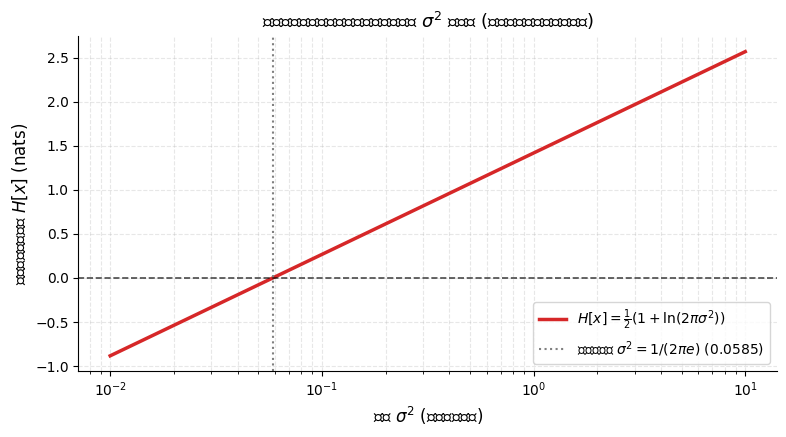

In [4]:
# ガウス分布の分散 sigma^2 と微分エントロピー H[x] の関係
sigma2_vals = np.logspace(-2, 1, 300)
h_vals = [differential_entropy_gaussian(s2) for s2 in sigma2_vals]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(sigma2_vals, h_vals, color='#d62728', lw=2.5, label=r'$H[x] = \frac{1}{2}(1 + \ln(2\pi \sigma^2))$')
ax.axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
critical_sigma2 = 1.0 / (2.0 * np.pi * np.e)
ax.axvline(critical_sigma2, color='gray', linestyle=':', lw=1.5,
           label=f'ゼロ交差点 $\sigma^2 = 1/(2\pi e)$ ({critical_sigma2:.4f})')

ax.set_xlabel(r'分散 $\sigma^2$ (対数スケール)', fontsize=12)
ax.set_ylabel(r'微分エントロピー $H[x]$ (nats)', fontsize=12)
ax.set_title('ガウス分布の微分エントロピーと分散 $\sigma^2$ の関係 (負のエントロピーの存在)', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


---
### 2.5.5 カルバック・ライブラー情報量 (Kullback–Leibler Divergence)

#### 1. 相対エントロピー (Relative Entropy) の定義
未知の真の確率分布 $p(x)$ を、モデルとなる近似分布 $q(x)$ を用いて近似・表現する場合を考えます。
真の分布 $p(x)$ に最適化された符号化方式を用いた場合、1シンボルあたりの平均情報量は $H[p] = -\int p(x)\ln p(x)dx$ です。
一方、誤ったモデル $q(x)$ に基づいて符号化した場合、必要な平均情報量は $-\int p(x)\ln q(x)dx$ となります。
この近似の不完全性によって**余分に必要となる追加の情報量**が **カルバック・ライブラー情報量 (Kullback–Leibler Divergence: KLダイバージェンス)** です：
$$\mathrm{KL}(p \parallel q) = - \int p(x) \ln q(x) dx - \left( - \int p(x) \ln p(x) dx \right) = - \int p(x) \ln \left( \frac{q(x)}{p(x)} \right) dx 	ag{2.100}$$

- **非対称性**: 一般に $\mathrm{KL}(p \parallel q) \neq \mathrm{KL}(q \parallel p)$ であり、数学的な距離（Metric）ではありません。

#### 2. 凸関数 (Convex Functions) の幾何学的性質 (Figure 2.15)
関数 $f(x)$ が凸関数（下に凸）であるとは、**任意の 2 点を結ぶ線分（弦 / chord）が常に関数のグラフの上側（または一致）にある**ことを意味します：
区間 $[a, b]$ 内の任意の点 $x_\lambda = \lambda a + (1 - \lambda)b$ ($0 \le \lambda \le 1$) に対し、凸性の定義式は：
$$f(\lambda a + (1 - \lambda)b) \le \lambda f(a) + (1 - \lambda) f(b) 	ag{2.101}$$

この定義は 2 階微分が常に非負 $f''(x) \ge 0$ であることと同値です（例: $x^2, -\ln x, x \ln x$）。

#### 3. イェンセンの不等式 (Jensen's Inequality) と KLダイバージェンスの非負性
式 (2.101) を数学的帰納法によって $M$ 点の重み付き和へと拡張したものが **イェンセンの不等式** です：
$$f\left( \sum_{i=1}^M \lambda_i x_i \right) \le \sum_{i=1}^M \lambda_i f(x_i) \quad \left(\lambda_i \ge 0, \sum_i \lambda_i = 1\right) 	ag{2.102}$$
期待値の記法を用いれば：
$$f(\mathbb{E}[x]) \le \mathbb{E}[f(x)] 	ag{2.103}$$
連続変数の積分形式では：
$$f\left( \int x p(x) dx \right) \le \int f(x) p(x) dx 	ag{2.104}$$

**【KLダイバージェンスの非負性証明】**
$-\ln(t)$ は厳密な凸関数（$\frac{d^2}{dt^2}(-\ln t) = \frac{1}{t^2} > 0$）です。
イェンセンの不等式 (2.104) を $f(t) = -\ln t$ および $t(x) = \frac{q(x)}{p(x)}$ に適用すると：
$$\mathrm{KL}(p \parallel q) = \int p(x) \left( -\ln \frac{q(x)}{p(x)} \right) dx \ge - \ln \left( \int p(x) \frac{q(x)}{p(x)} dx \right) = - \ln \left( \int q(x) dx \right) = - \ln 1 = 0 	ag{2.105}$$
$-\ln t$ は狭義凸関数であるため、等号成立は $t(x) = \frac{q(x)}{p(x)} = 1$、すなわち **すべての $x$ で $p(x) = q(x)$ のときに限られます**。

#### 4. 機械学習における最尤推定とKLダイバージェンスの関係 (式 2.106)
未知の真の分布 $p(x)$ からの観測データ $\{x_1, \dots, x_N\}$ が与えられたとき、パラメータ $\theta$ を持つモデル分布 $q(x|\theta)$ で $p(x)$ を近似することを考えます。
真の分布 $p(x)$ に関する期待値をサンプル平均でモンテカルロ近似すると：
$$\mathrm{KL}(p \parallel q_\theta) \simeq \frac{1}{N} \sum_{n=1}^N \left( - \ln q(x_n | \theta) + \ln p(x_n) \right) = - \frac{1}{N} \sum_{n=1}^N \ln q(x_n | \theta) + \text{const} 	ag{2.106}$$
第 2 項 $\frac{1}{N} \sum \ln p(x_n)$ はパラメータ $\theta$ に依存しません。
したがって、**モデル $q(x|\theta)$ と真の分布 $p(x)$ のKLダイバージェンスを最小化することは、訓練データに対する負の対数尤度を最小化（対数尤度を最大化）することと完全に等価**です。


Font 'default' does not have a glyph for '\u51f8' [U+51f8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u306b' [U+306b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u304a' [U+304a], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u70b9' [U+70b9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u51f8' [U+51f8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Figure saved successfully to: result/fig2_15_convex_function_jensen.png


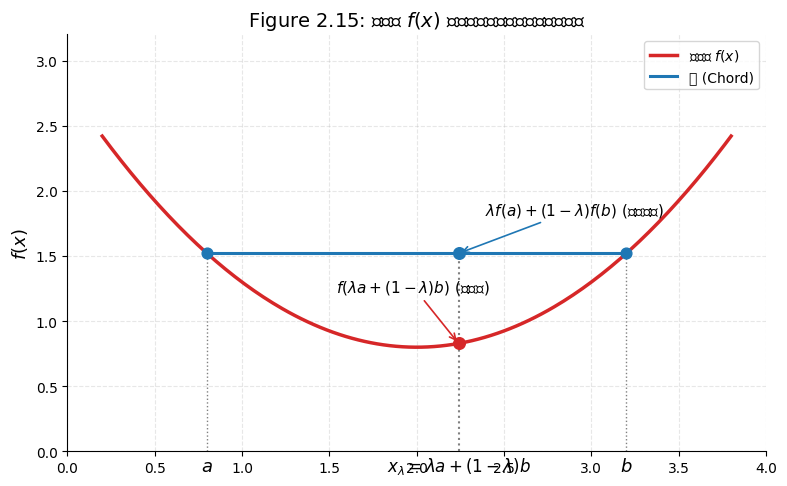

In [5]:
# Figure 2.15 再現: 凸関数 f(x) と弦 (Chord) の幾何学的関係 (イェンセンの不等式の基礎)
x_curve = np.linspace(0.2, 3.8, 200)
# 教科書の図に合わせて f(x) = (x - 2)^2 + 0.5 または凸な多項式
f_convex = lambda x: 0.5 * (x - 2.0)**2 + 0.8

a = 0.8
b = 3.2
lam = 0.4  # 内分比
x_lam = lam * a + (1 - lam) * b

f_a = f_convex(a)
f_b = f_convex(b)
f_x_lam = f_convex(x_lam)
chord_val = lam * f_a + (1 - lam) * f_b

fig, ax = plt.subplots(figsize=(8, 5))

# 凸関数のプロット (赤線)
ax.plot(x_curve, f_convex(x_curve), color='#d62728', lw=2.5, label=r'凸関数 $f(x)$')

# 弦のプロット (青線)
ax.plot([a, b], [f_a, f_b], color='#1f77b4', lw=2.2, label='弦 (Chord)')

# 点と破線の描画
ax.scatter([a, b], [f_a, f_b], color='#1f77b4', s=60, zorder=5)
ax.scatter([x_lam], [f_x_lam], color='#d62728', s=70, zorder=5)
ax.scatter([x_lam], [chord_val], color='#1f77b4', s=70, zorder=5)

# 垂直破線
ax.plot([x_lam, x_lam], [0, chord_val], color='gray', linestyle=':', lw=1.5)
ax.plot([a, a], [0, f_a], color='gray', linestyle=':', lw=1.0)
ax.plot([b, b], [0, f_b], color='gray', linestyle=':', lw=1.0)

# ラベルと注記
ax.text(a, -0.15, '$a$', ha='center', fontsize=13)
ax.text(b, -0.15, '$b$', ha='center', fontsize=13)
ax.text(x_lam, -0.15, r'$x_\lambda = \lambda a + (1-\lambda)b$', ha='center', fontsize=12)

ax.annotate(r'$f(\lambda a + (1-\lambda)b)$ (関数値)', xy=(x_lam, f_x_lam), xytext=(x_lam - 0.7, f_x_lam + 0.4),
            arrowprops=dict(arrowstyle='->', lw=1.2, color='#d62728'), fontsize=11)
ax.annotate(r'$\lambda f(a) + (1-\lambda)f(b)$ (弦上の点)', xy=(x_lam, chord_val), xytext=(x_lam + 0.15, chord_val + 0.3),
            arrowprops=dict(arrowstyle='->', lw=1.2, color='#1f77b4'), fontsize=11)

ax.set_ylim([0, 3.2])
ax.set_xlim([0.0, 4.0])
ax.set_ylabel('$f(x)$', fontsize=13)
ax.set_title('Figure 2.15: 凸関数 $f(x)$ における弦と関数値の位置関係', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

save_plot(fig, 'result/fig2_15_convex_function_jensen.png')
plt.show()


---
### 2.5.6 条件付きエントロピー (Conditional Entropy)

#### 1. 定義と連鎖律 (Chain Rule)
2 つの確率変数 $x, y$ の同時分布 $p(x, y)$ を考えます。
もし変数 $x$ の値がすでに観測されて既知である場合、$y$ の値を特定するためにさらに必要となる追加の情報量は $-\ln p(y|x)$ です。
この追加情報量の同時分布に関する期待値を **条件付きエントロピー (Conditional Entropy)** と呼びます：
$$H[y|x] = - \iint p(x, y) \ln p(y|x) dx dy 	ag{2.107}$$

乗法定理 $p(x, y) = p(y|x) p(x)$ より $\ln p(x, y) = \ln p(y|x) + \ln p(x)$ であるため：
$$H[x, y] = - \iint p(x, y) \ln p(x, y) dx dy = - \iint p(x, y) \ln p(y|x) dx dy - \iint p(x, y) \ln p(x) dx dy$$
周辺化 $\int p(x, y) dy = p(x)$ を用いると：
$$H[x, y] = H[y|x] + H[x] 	ag{2.108}$$
が成立します。すなわち、**「$x$ と $y$ のペアを記述するために必要な総情報量は、$x$ 単独を記述する情報量と、$x$ が与えられた下で $y$ を特定するための追加情報量の和に等しい」** という直観的な加法性が成り立ちます。

---
### 2.5.7 相互情報量 (Mutual Information)

#### 1. 独立性とKLダイバージェンスによる定式化
2 つの変数 $x$ と $y$ が独立であれば、結合分布は周辺分布の積に分解します：$p(x, y) = p(x)p(y)$。
変数がどの程度独立から離れているかを測るため、同時分布 $p(x, y)$ と独立仮定の積分布 $p(x)p(y)$ との間の KLダイバージェンスを定義します：
$$I[x, y] \equiv \mathrm{KL}(p(x, y) \parallel p(x)p(y)) = - \iint p(x, y) \ln \left( \frac{p(x)p(y)}{p(x, y)} \right) dx dy 	ag{2.109}$$
これを **相互情報量 (Mutual Information)** と呼びます。

#### 2. 相互情報量の基本性質
1. **非負性**: KLダイバージェンスの性質より $I[x, y] \ge 0$ であり、$x$ と $y$ が独立であるとき、かつそのときに限り $I[x, y] = 0$ となります。
2. **条件付きエントロピーとの関係式**:
   $$I[x, y] = H[x] - H[x|y] = H[y] - H[y|x] = H[x] + H[y] - H[x, y] 	ag{2.110}$$
   相互情報量は「$y$ の値を知ることによって、$x$ に関する不確実性（エントロピー）がどれだけ減少するか」を表します。

#### 3. 2次元ガウス分布における相互情報量の解析解
共分散行列 $\mathbf{\Sigma} = \begin{pmatrix} \sigma_x^2 & \rho \sigma_x \sigma_y \\ \rho \sigma_x \sigma_y & \sigma_y^2 \end{pmatrix}$ を持つ2次元ガウス分布において：
$$H[x] = \frac{1}{2}(1 + \ln(2\pi \sigma_x^2)), \quad H[y] = \frac{1}{2}(1 + \ln(2\pi \sigma_y^2))$$
同時微分エントロピーは：
$$H[x, y] = 1 + \ln(2\pi) + \frac{1}{2}\ln |\mathbf{\Sigma}| = 1 + \ln(2\pi) + \frac{1}{2}\ln(\sigma_x^2 \sigma_y^2 (1 - \rho^2))$$
相互情報量を計算すると、各分散項が相殺し、**相関係数 $\rho$ のみに依存する極めて美しい解析解**が得られます：
$$I[x, y] = H[x] + H[y] - H[x, y] = - \frac{1}{2} \ln(1 - \rho^2)$$
- $\rho = 0$（無相関・独立）のとき: $I[x, y] = -\frac{1}{2}\ln(1) = 0$
- $|\rho| \to 1$（完全な相関・決定論的関係）のとき: $I[x, y] \to +\infty$


Font 'default' does not have a glyph for '\u76f8' [U+76f8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4fc2' [U+4fc2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u76f8' [U+76f8], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4fc2' [U+4fc2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22577 (\N{CJK UNIFIED IDEOGRAPH-5831}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35542 (\N{CJK UNIFIED IDEOGRAPH-8AD6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/I

Font 'default' does not have a glyph for '\u4f53' [U+4f53], substituting with a dummy symbol.


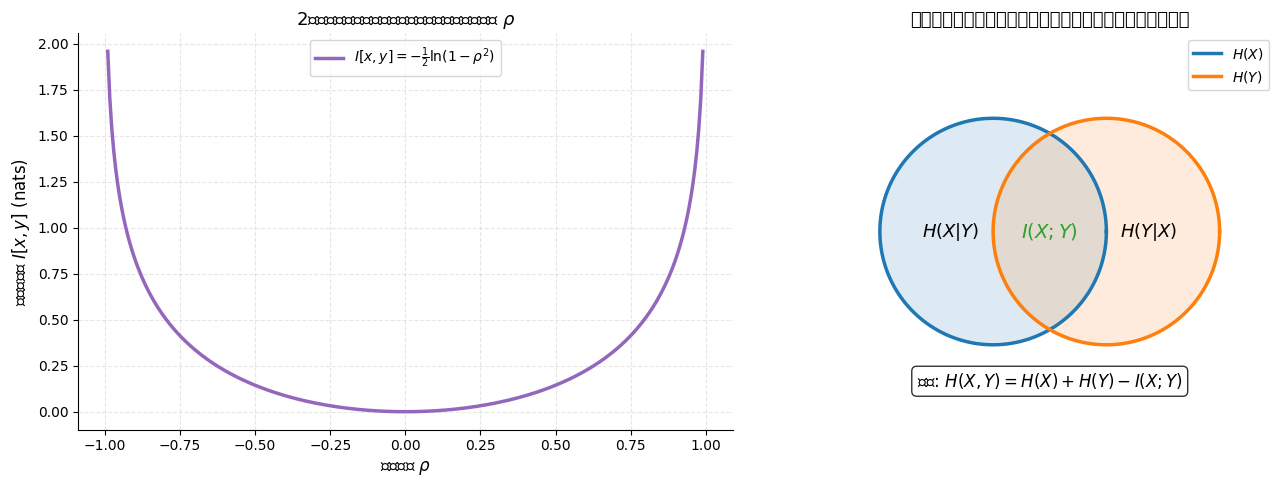

In [6]:
# 相互情報量 I[x, y] と相関係数 rho の関係、および情報理論ベン図の可視化
rhos = np.linspace(-0.99, 0.99, 300)
mi_values = [-0.5 * np.log(1.0 - r**2) for r in rhos]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左プロット: 2次元ガウス分布の相互情報量
ax1.plot(rhos, mi_values, color='#9467bd', lw=2.5, label=r'$I[x, y] = -\frac{1}{2}\ln(1 - \rho^2)$')
ax1.set_xlabel(r'相関係数 $\rho$', fontsize=12)
ax1.set_ylabel('相互情報量 $I[x, y]$ (nats)', fontsize=12)
ax1.set_title(r'2次元ガウス分布における相互情報量と相関係数 $\rho$', fontsize=13)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper center')

# 右プロット: 情報理論の関係図 (ベン図風可視化)
# 円を描画
theta = np.linspace(0, 2*np.pi, 200)
circle_x1 = 0.4 * np.cos(theta) - 0.2
circle_y1 = 0.4 * np.sin(theta)
circle_x2 = 0.4 * np.cos(theta) + 0.2
circle_y2 = 0.4 * np.sin(theta)

ax2.plot(circle_x1, circle_y1, color='#1f77b4', lw=2.5, label=r'$H(X)$')
ax2.plot(circle_x2, circle_y2, color='#ff7f0e', lw=2.5, label=r'$H(Y)$')
ax2.fill(circle_x1, circle_y1, color='#1f77b4', alpha=0.15)
ax2.fill(circle_x2, circle_y2, color='#ff7f0e', alpha=0.15)

ax2.text(-0.35, 0.0, r'$H(X|Y)$', fontsize=13, ha='center', va='center', weight='bold')
ax2.text(0.35, 0.0, r'$H(Y|X)$', fontsize=13, ha='center', va='center', weight='bold')
ax2.text(0.0, 0.0, r'$I(X; Y)$', fontsize=14, ha='center', va='center', weight='bold', color='#2ca02c')
ax2.text(0.0, -0.55, r'全体: $H(X, Y) = H(X) + H(Y) - I(X; Y)$', fontsize=12, ha='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlim([-0.8, 0.8])
ax2.set_ylim([-0.7, 0.7])
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('情報理論におけるエントロピーと相互情報量のベン図関係', fontsize=13)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


---
### まとめ: 第2章 2.5節で学んだ最重要概念

1. **シャノンエントロピー**:
   $$H[x] = -\sum_x p(x) \log_2 p(x)$$
   可逆圧縮に必要な平均ビット数の理論的限界（シャノンの無雑音符号化定理）。
2. **物理学との等価性**:
   多重度 $W = \frac{N!}{\prod_i n_i!}$ にスターリングの近似を適用することで、統計力学的エントロピー $\frac{1}{N}\ln W$ とシャノンエントロピーが一致。離散分布の最大エントロピー分布は一様分布。
3. **微分エントロピー**:
   $$H[x] = -\int p(x)\ln p(x)dx$$
   連続変数では負の値を取り得る。平均と分散を固定したとき、微分エントロピーを最大化する連続分布は**ガウス分布**。
4. **KLダイバージェンス**:
   $$\mathrm{KL}(p \parallel q) = -\int p(x) \ln\frac{q(x)}{p(x)}dx \ge 0$$
   イェンセンの不等式 $f(\mathbb{E}[x]) \le \mathbb{E}[f(x)]$ から非負性が証明され、最尤推定はKLダイバージェンス最小化と等価。
5. **相互情報量**:
   $$I[x, y] = H[x] - H[x|y] = H[y] - H[y|x] = \mathrm{KL}(p(x, y) \parallel p(x)p(y)) \ge 0$$
   2つの変数の依存度を測定し、独立のときのみ 0 となる。
